# EEG Signal Analysis using Python

## Introduction
This project performs preprocessing and frequency-domain analysis of EEG signals using the MNE library in Google Colab. The objective is to extract Alpha and Beta frequency bands and analyze their power characteristics.

In [1]:
!pip install mne


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 83.2 MB/s eta 0:00:00


In [2]:
import mne
from mne.datasets import eegbci

# Download dataset automatically
subject = 1
runs = [1]  # keep small
files = eegbci.load_data(subject, runs)

raw = mne.io.read_raw_edf(files[0], preload=True)
raw

Using default location ~/mne_data for EEGBCI...
Creating /root/mne_data


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
Download complete in 35s (1.2 MB)
Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...


<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~4.8 MiB, data loaded>

Using matplotlib as 2D backend.


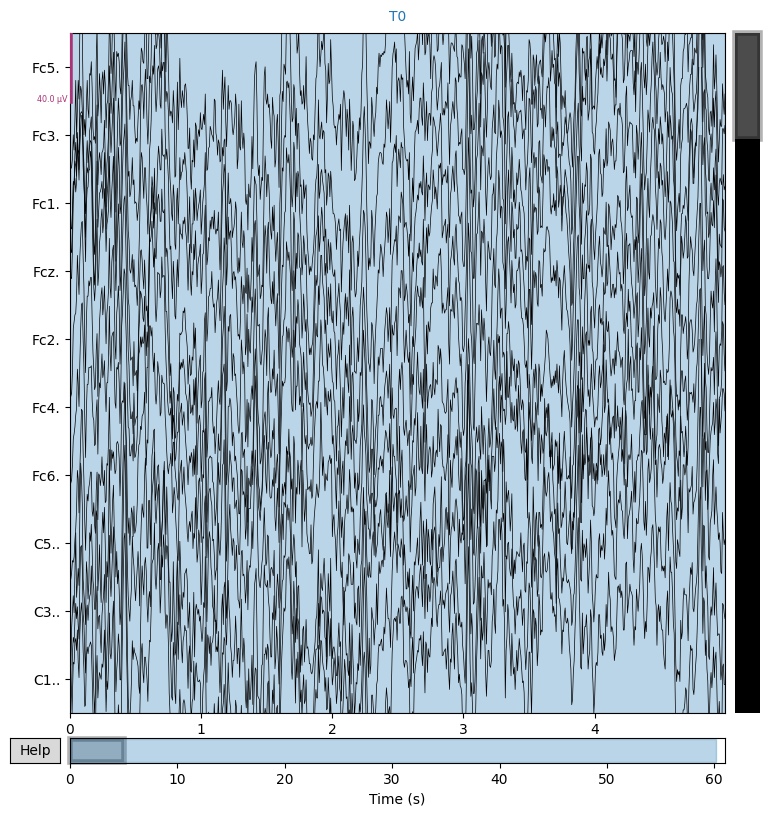

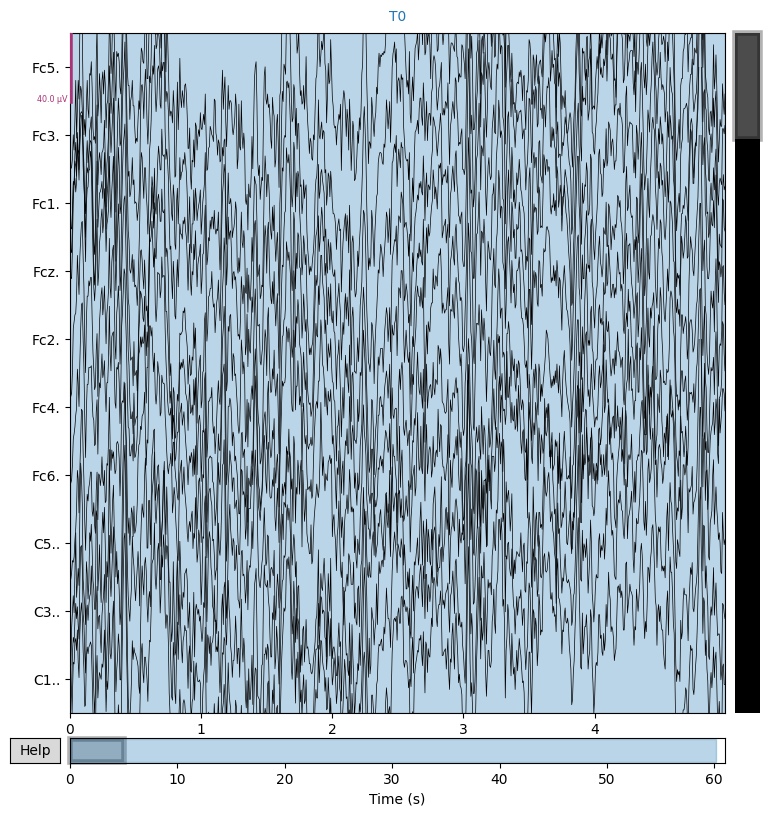

In [3]:
raw.plot(n_channels=10, duration=5)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)



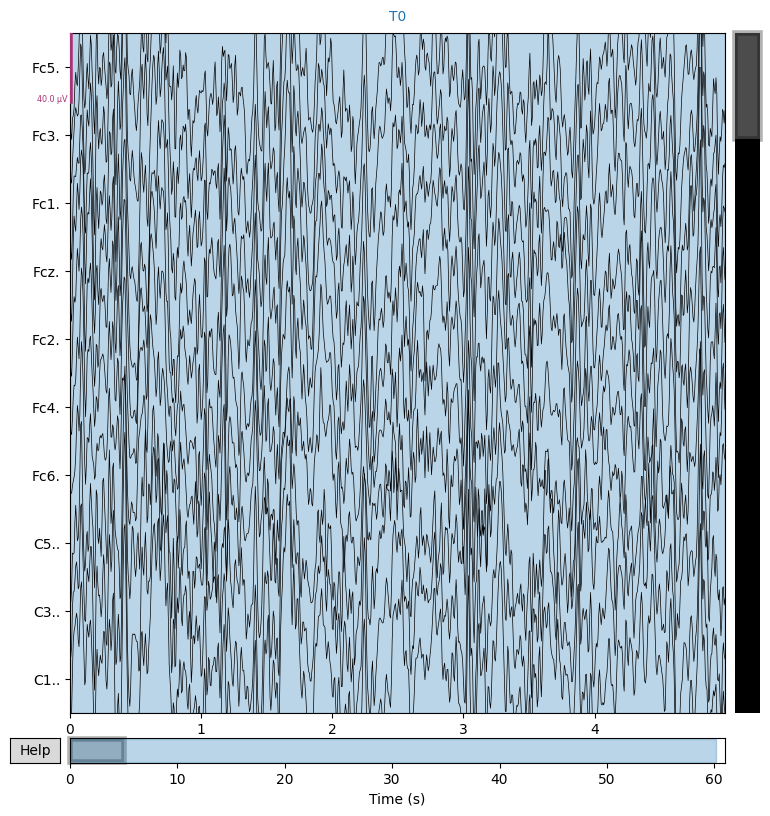

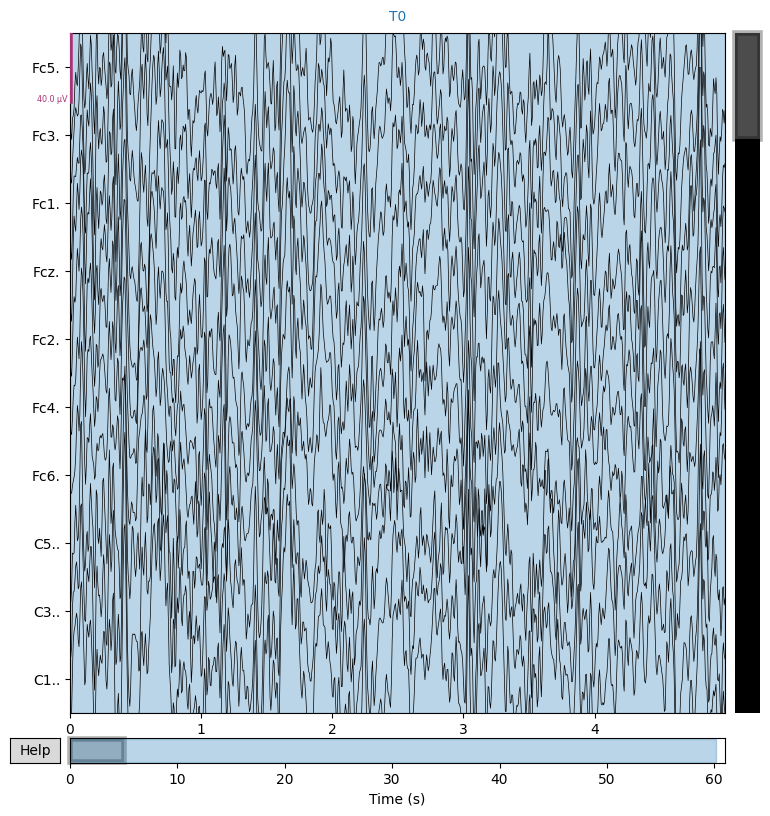

In [4]:
raw_filtered = raw.copy().filter(1., 40.)
raw_filtered.plot(n_channels=10, duration=5)

In [5]:
alpha = raw.copy().filter(8., 12.)
beta = raw.copy().filter(13., 30.)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 265 samples (1.656 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge:

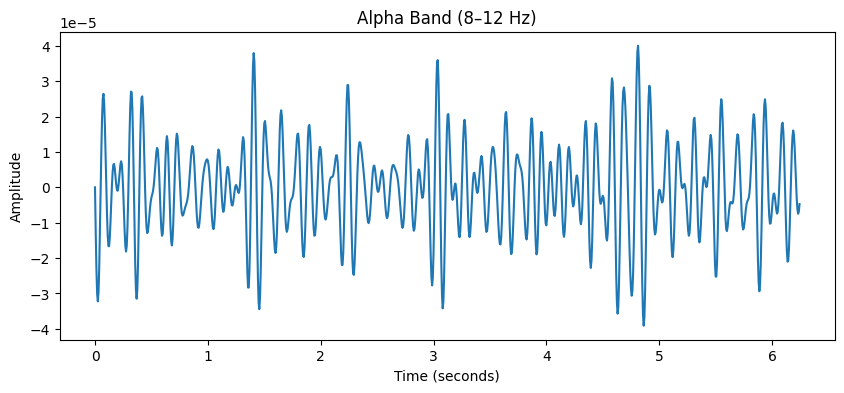

In [6]:
import matplotlib.pyplot as plt

data_alpha, times = alpha.get_data(return_times=True)

plt.figure(figsize=(10,4))
plt.plot(times[:1000], data_alpha[0][:1000])
plt.title("Alpha Band (8–12 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

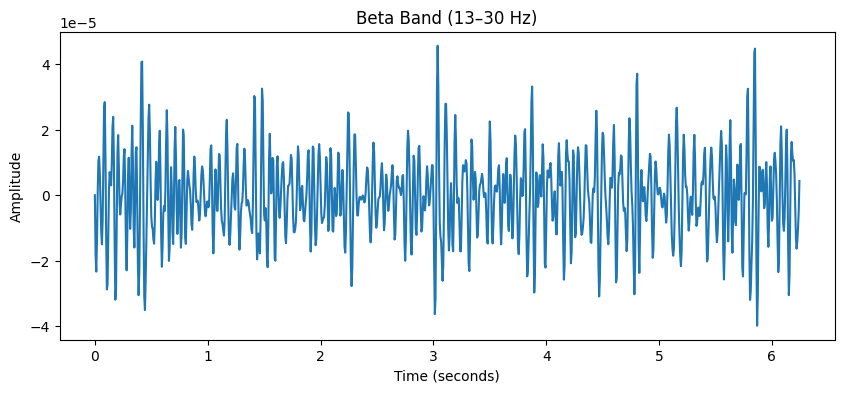

In [7]:
data_beta, times = beta.get_data(return_times=True)

plt.figure(figsize=(10,4))
plt.plot(times[:1000], data_beta[0][:1000])
plt.title("Beta Band (13–30 Hz)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()

Effective window size : 12.800 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_358/4197613511.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  psd.plot()


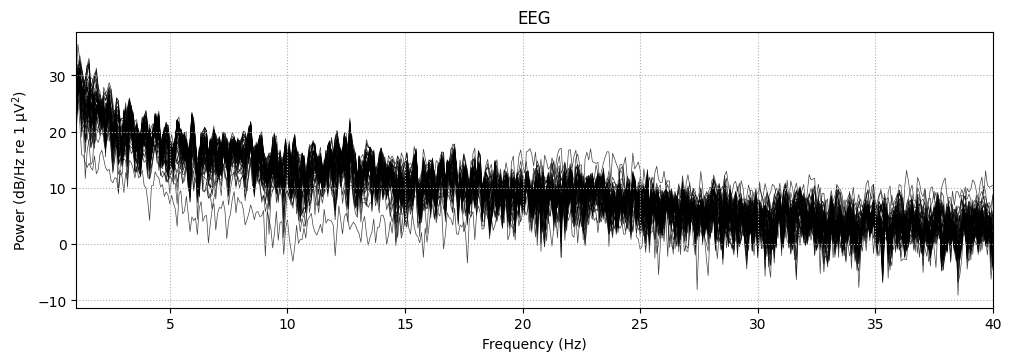

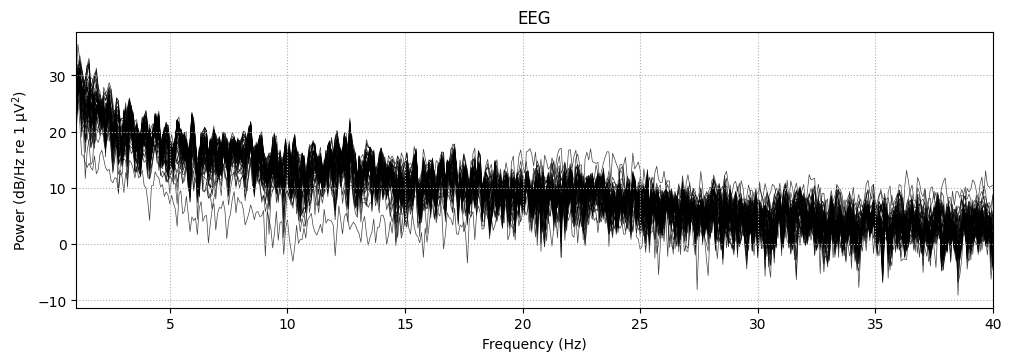

In [8]:
psd = raw.compute_psd(fmin=1, fmax=40)
psd.plot()

In [9]:
import numpy as np

psds, freqs = raw.compute_psd(fmin=1, fmax=40).get_data(return_freqs=True)

# Define bands
alpha_band = (8, 12)
beta_band = (13, 30)

# Find frequency indices
alpha_idx = np.logical_and(freqs >= alpha_band[0], freqs <= alpha_band[1])
beta_idx = np.logical_and(freqs >= beta_band[0], freqs <= beta_band[1])

# Compute mean power
alpha_power = psds[:, alpha_idx].mean()
beta_power = psds[:, beta_idx].mean()

print("Average Alpha Power:", alpha_power)
print("Average Beta Power:", beta_power)

Effective window size : 12.800 (s)
Average Alpha Power: 2.8862157260121493e-11
Average Beta Power: 9.494263172526383e-12


## Interpretation and Observations

The raw EEG signals initially showed low-frequency drift and high-frequency noise, which is common in physiological recordings.

After applying a band-pass filter (1–40 Hz), the signal quality improved significantly by removing unwanted artifacts and preserving relevant brain activity frequencies.

The Alpha band (8–12 Hz) and Beta band (13–30 Hz) were successfully extracted. Alpha waves are generally associated with relaxed states, while Beta waves are linked to active cognitive processing.

Power Spectral Density (PSD) analysis revealed higher signal power in lower frequency ranges, which aligns with typical EEG characteristics.

The computed average band power values provide quantitative insight into frequency-domain brain activity.

## Conclusion

The EEG signals were successfully filtered and analyzed in both time and frequency domains. The extraction of Alpha and Beta bands, along with band power computation, demonstrates fundamental signal processing techniques used in Brain–Computer Interface (BCI) research.